# Layer 3: Rule-Based Precursor Risk Scorer
## Transparent, Auditable Incident Prioritisation · NASA ASRS 2018–2026

**Goal:** Assign every incident a precursor risk score (0–1) that reflects the density of safety-critical language in the narrative — so analysts can immediately prioritise the highest-risk incidents for review.

### Why rule-based, not ML?

In a safety-critical proof of concept, **every score component must be auditable by a safety analyst who is not a data scientist**.  
A rule-based scorer tells you exactly why an incident scored 0.8: it matched 2 fatigue terms and 2 near-miss terms.  
An ML model tells you the score was 0.8 — and nothing else that a non-technical regulator can defend.

| Design decision | Choice | Why |
| --- | --- | --- |
| **Scoring method** | Weighted term-count sum | Fully auditable; each term is human-interpretable |
| **Components** | 5 human-factors categories | Grounded in ASRS Human Factors taxonomy |
| **Cap per component** | 2 hits maximum | Prevents a single verbose narrative dominating the score |
| **Normalisation** | `score = raw / MAX_RAW_SCORE` | Forces 0–1 range, comparable across all incidents |
| **High-risk threshold** | 90th percentile | Top 10% for analyst review queue — operationally feasible |


In [16]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [17]:
# Import the scorer to show it's a live callable module, not a black box
from src.risk_scorer import (
    PRECURSOR_TERMS, COMPONENT_WEIGHTS, MAX_RAW_SCORE, score_incident
)

print("=== SCORING FORMULA ===")
print(f"MAX_RAW_SCORE = sum(2 × weight for each component) = {MAX_RAW_SCORE}")
print(f"score = min(raw_score / {MAX_RAW_SCORE}, 1.0)")
print()
print(f"{'Component':<22}  {'Weight':>6}  {'Max contrib':>11}  Terms (sample)")
print("-" * 80)
for comp, weight in sorted(COMPONENT_WEIGHTS.items(), key=lambda x: -x[1]):
    max_contrib = 2 * weight
    terms_sample = ', '.join(PRECURSOR_TERMS[comp][:4]) + '...'
    print(f"  {comp:<20}  {weight:>6.1f}  {max_contrib:>11.1f}  {terms_sample}")
print()
print("Term count per component is capped at 2 before applying the weight.")

=== SCORING FORMULA ===
MAX_RAW_SCORE = sum(2 × weight for each component) = 20.0
score = min(raw_score / 20.0, 1.0)

Component               Weight  Max contrib  Terms (sample)
--------------------------------------------------------------------------------
  fatigue                  2.5          5.0  fatigue, tired, exhausted, rest period...
  near_miss                2.5          5.0  nearly, almost, narrowly, close call...
  comm_breakdown           2.0          4.0  miscommunication, misunderstood, wrong frequency, unclear...
  procedure_deviation      1.5          3.0  skipped, omitted, forgot, failed to...
  urgency                  1.5          3.0  emergency, immediately, critical, serious...

Term count per component is capped at 2 before applying the weight.


In [18]:
# Show the scorer is fully transparent — live scoring of two example narratives
examples = [
    ("Low scorer",
     "Aircraft requested frequency change. ATC approved. No issues noted."),
    ("High scorer",
     "Crew was fatigued after a long duty day. We nearly missed the runway after "
     "a communication breakdown with ATC. Almost declared emergency. "
     "Crew did not check NOTAM. Fatigue was a serious factor."),
]
for label, text in examples:
    result = score_incident(text)
    score = result.pop('precursor_score')
    active = {k.replace('component_',''): v for k,v in result.items() if v > 0}
    print(f"{label}: score = {score:.3f}")
    print(f"  Text: '{text[:90]}...'" if len(text)>90 else f"  Text: '{text}'")
    print(f"  Active components: {active}")
    print()

Low scorer: score = 0.000
  Text: 'Aircraft requested frequency change. ATC approved. No issues noted.'
  Active components: {}

High scorer: score = 0.900
  Text: 'Crew was fatigued after a long duty day. We nearly missed the runway after a communication...'
  Active components: {'fatigue': 2, 'comm_breakdown': 1, 'near_miss': 2, 'procedure_deviation': 2, 'urgency': 2}



In [19]:
# Load Layer 3 enriched dataset
asrs = pd.read_parquet('../outputs/data/asrs_layer3.parquet')
asrs['date'] = pd.to_datetime(asrs['date'], errors='coerce')
asrs_valid = asrs[asrs['date'].dt.year >= 2018].copy()

comp_cols = [c for c in asrs.columns if c.startswith('component_')]
threshold_90 = asrs_valid['precursor_score'].quantile(0.90)

print(f"Corpus           : {len(asrs_valid):,} incidents")
print(f"Score range      : {asrs_valid['precursor_score'].min():.3f} – {asrs_valid['precursor_score'].max():.3f}")
print(f"Mean / median    : {asrs_valid['precursor_score'].mean():.3f} / {asrs_valid['precursor_score'].median():.3f}")
print(f"90th pct (threshold): {threshold_90:.3f}")
high_risk = asrs_valid['high_precursor_risk'].sum()
print(f"High-risk (top 10%): {high_risk:,} incidents ({high_risk/len(asrs_valid)*100:.1f}%)")
print()
print("Zero-score incidents (no precursor terms found):")
zero = (asrs_valid['precursor_score'] == 0).sum()
print(f"  {zero:,} ({zero/len(asrs_valid)*100:.1f}%) — these are routine operational reports")

Corpus           : 43,825 incidents
Score range      : 0.000 – 0.900
Mean / median    : 0.094 / 0.075
90th pct (threshold): 0.250
High-risk (top 10%): 4,889 incidents (11.2%)

Zero-score incidents (no precursor terms found):
  18,127 (41.4%) — these are routine operational reports


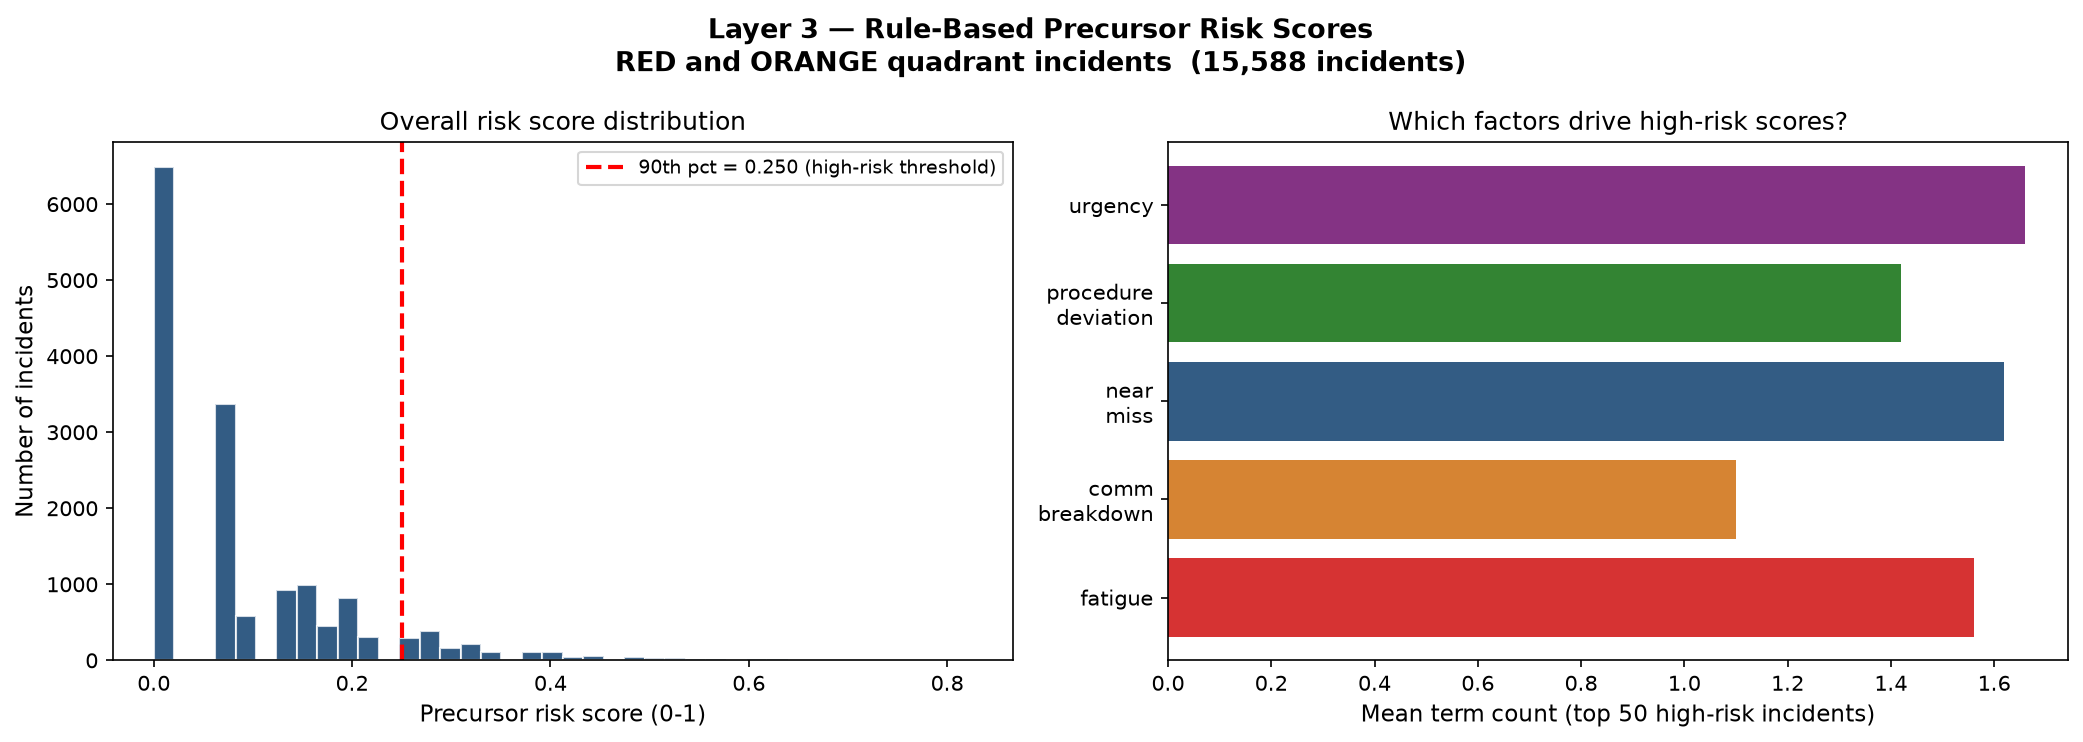

In [20]:
# Risk distribution chart — the Layer 3 centrepiece output
display(Image('../outputs/figures/precursor_risk_distribution.png'))

---
## Component Analysis — What Drives High Scores?

In [21]:
# Component prevalence — what % of incidents mention each precursor type at least once?
prevalence = pd.DataFrame({
    'Component': [c.replace('component_','').replace('_',' ') for c in comp_cols],
    'Weight': [COMPONENT_WEIGHTS[c.replace('component_','')] for c in comp_cols],
    'Incidents with ≥1 hit': [(asrs_valid[c] > 0).sum() for c in comp_cols],
    '% of corpus': [(asrs_valid[c] > 0).mean() * 100 for c in comp_cols],
    'Mean hits (when present)': [
        asrs_valid.loc[asrs_valid[c] > 0, c].mean() for c in comp_cols
    ],
})
prevalence = prevalence.sort_values('Weight', ascending=False)
prevalence['% of corpus'] = prevalence['% of corpus'].round(1)
prevalence['Mean hits (when present)'] = prevalence['Mean hits (when present)'].round(2)
prevalence.index = range(1, len(prevalence)+1)
prevalence

,Component,Weight,Incidents with ≥1 hit,% of corpus,Mean hits (when present)
1,fatigue,2.5,1451,3.3,1.53
2,near miss,2.5,7702,17.6,1.13
3,comm breakdown,2.0,5884,13.4,1.16
4,procedure deviation,1.5,7532,17.2,1.16
5,urgency,1.5,16391,37.4,1.23


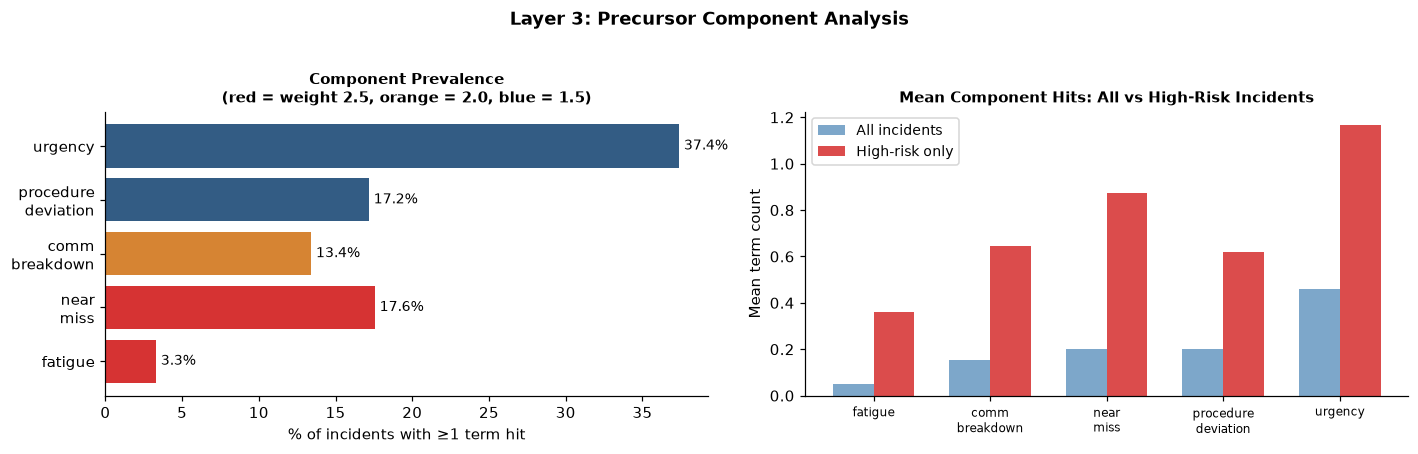

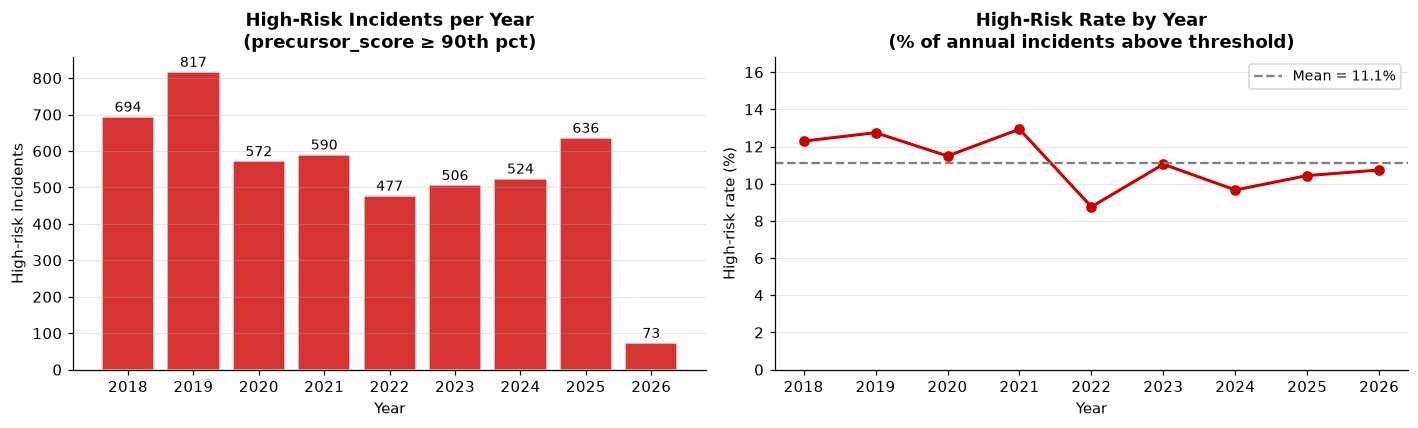

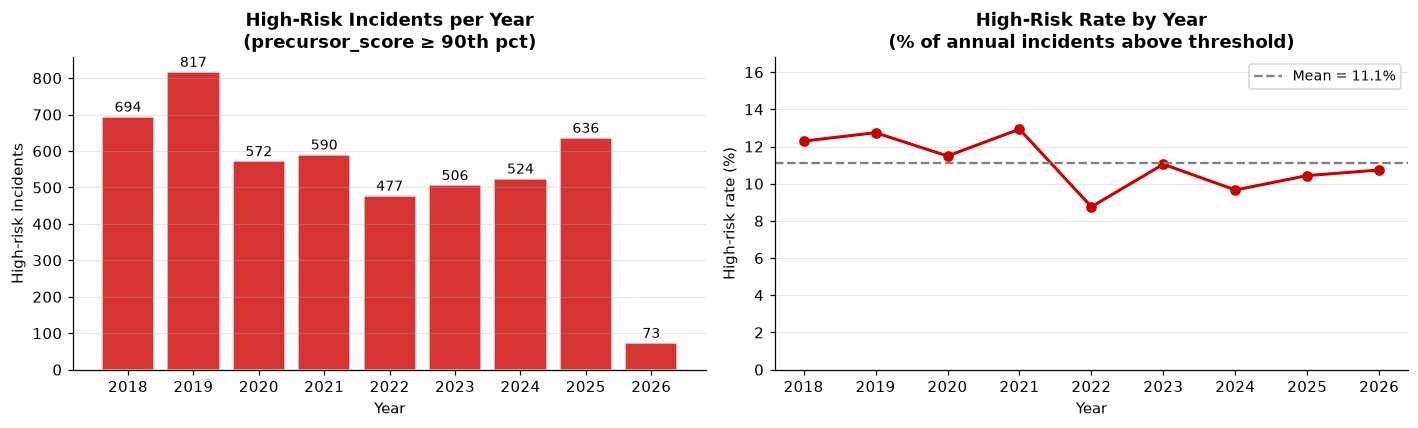

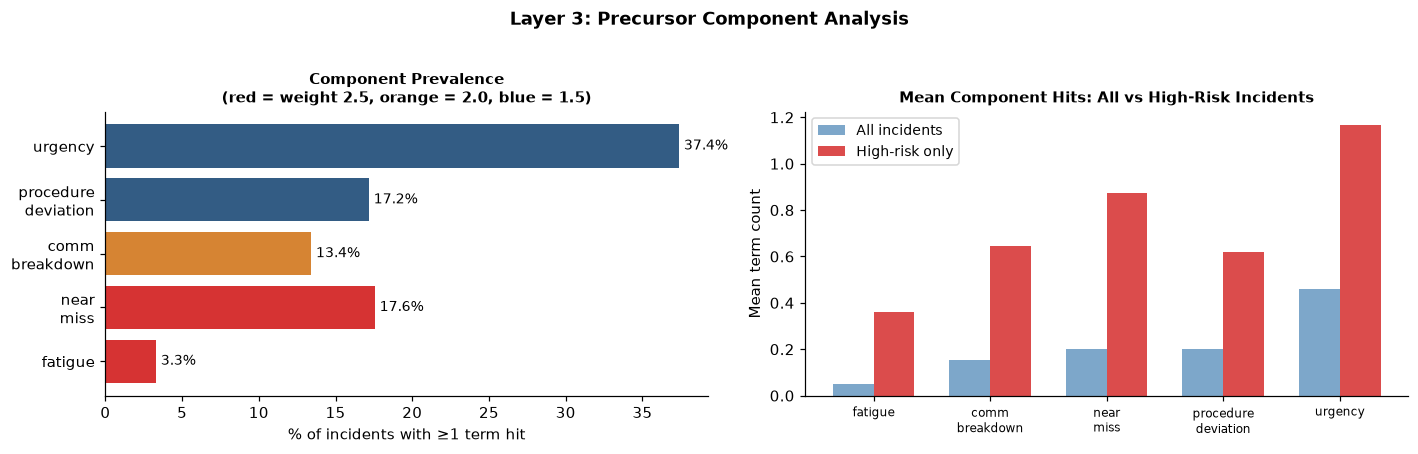

In [22]:
# Component co-occurrence — when fatigue appears, what else tends to appear?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: component prevalence bar chart
comp_labels = [c.replace('component_','').replace('_','\n') for c in comp_cols]
comp_pcts = [(asrs_valid[c] > 0).mean() * 100 for c in comp_cols]
comp_weights = [COMPONENT_WEIGHTS[c.replace('component_','')] for c in comp_cols]

# Sort by weight
order = sorted(range(len(comp_cols)), key=lambda i: -comp_weights[i])
axes[0].barh([comp_labels[i] for i in order], [comp_pcts[i] for i in order],
             color=['#cc0000','#cc0000','#cc6600','#003366','#003366'],
             alpha=0.8)
for i, v in enumerate([comp_pcts[j] for j in order]):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('% of incidents with ≥1 term hit', fontsize=10)
axes[0].set_title('Component Prevalence\n(red = weight 2.5, orange = 2.0, blue = 1.5)',
                  fontsize=10, fontweight='bold')

# Right: mean score for HIGH-RISK incidents by component combination
hr = asrs_valid[asrs_valid['high_precursor_risk'] == 1]
comp_means_hr = [hr[c].mean() for c in comp_cols]
comp_means_all = [asrs_valid[c].mean() for c in comp_cols]
x = np.arange(len(comp_cols))
width = 0.35
axes[1].bar(x - width/2, comp_means_all, width, label='All incidents', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, comp_means_hr, width, label='High-risk only', color='#cc0000', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('component_','').replace('_','\n') for c in comp_cols], fontsize=8)
axes[1].set_ylabel('Mean term count', fontsize=10)
axes[1].set_title('Mean Component Hits: All vs High-Risk Incidents',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Layer 3: Precursor Component Analysis', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

---
## High-Risk Incidents — Temporal and Quadrant Breakdown

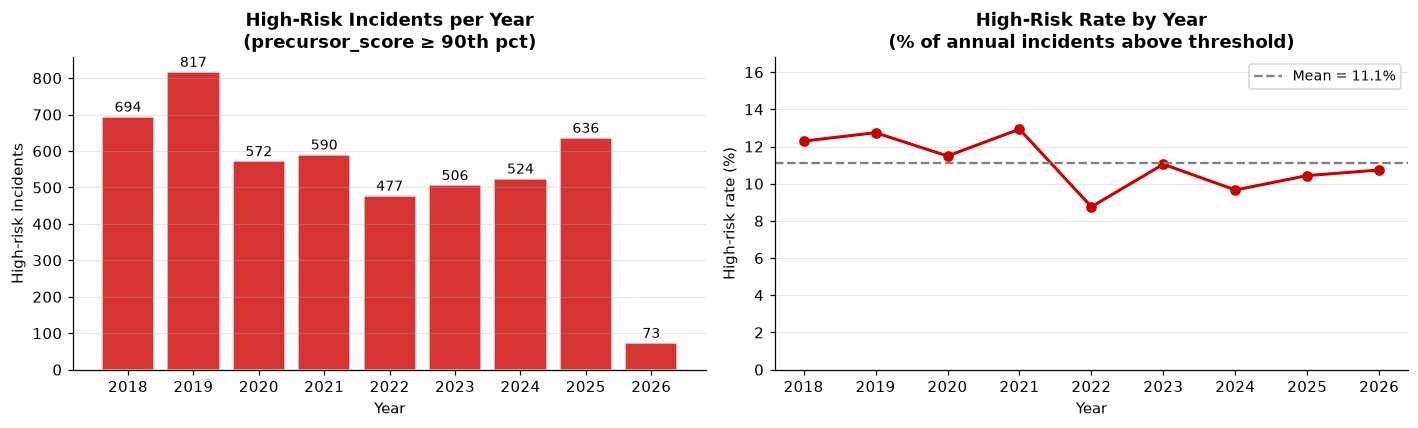

In [23]:
# High-risk incidents over time
hr = asrs_valid[asrs_valid['high_precursor_risk'] == 1]
hr_by_year = hr.groupby(hr['date'].dt.year)['ACN'].count()
total_by_year = asrs_valid.groupby(asrs_valid['date'].dt.year)['ACN'].count()
hr_rate = (hr_by_year / total_by_year * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: count by year
axes[0].bar(hr_by_year.index, hr_by_year.values, color='#cc0000', alpha=0.8, edgecolor='white')
for x, v in zip(hr_by_year.index, hr_by_year.values):
    axes[0].text(x, v + 5, str(v), ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('High-risk incidents')
axes[0].set_title('High-Risk Incidents per Year\n(precursor_score ≥ 90th pct)', fontweight='bold')
axes[0].set_xticks(hr_by_year.index)
axes[0].grid(axis='y', alpha=0.3)

# Right: rate by year — is the proportion changing?
axes[1].plot(hr_rate.index, hr_rate.values, marker='o', color='#cc0000', linewidth=2)
axes[1].axhline(hr_rate.mean(), color='grey', linestyle='--', linewidth=1.5,
                label=f'Mean = {hr_rate.mean():.1f}%')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('High-risk rate (%)')
axes[1].set_title('High-Risk Rate by Year\n(% of annual incidents above threshold)', fontweight='bold')
axes[1].set_xticks(hr_rate.index)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, hr_rate.max() * 1.3)

plt.tight_layout()

In [24]:
# Risk score vs quadrant — are they correlated or independent signals?
quad_stats = asrs_valid.groupby('quadrant')['precursor_score'].agg(['mean','median','max','count'])
quad_stats['high_risk_count'] = asrs_valid.groupby('quadrant')['high_precursor_risk'].sum()
quad_stats['high_risk_rate'] = (quad_stats['high_risk_count'] / quad_stats['count'] * 100).round(1)
quad_stats = quad_stats.round(3)
quad_stats.columns = ['Mean score', 'Median score', 'Max score', 'Total incidents',
                       'High-risk count', 'High-risk rate %']
print(quad_stats.to_string())
print()
print("Key insight: high-risk rate is similar across all quadrants (~10-12%).")
print("precursor_score and quadrant are largely independent signals —")
print("they measure different dimensions of risk (narrative language vs statistical anomaly/novelty).")

          Mean score  Median score  Max score  Total incidents  High-risk count  High-risk rate %
quadrant                                                                                         
GREEN          0.094         0.075      0.900            26863             3090              11.5
ORANGE         0.093         0.075      0.825            14770             1574              10.7
RED            0.085         0.075      0.550              818               74               9.0
YELLOW         0.095         0.075      0.650             1374              151              11.0

Key insight: high-risk rate is similar across all quadrants (~10-12%).
precursor_score and quadrant are largely independent signals —
they measure different dimensions of risk (narrative language vs statistical anomaly/novelty).


### Why RED quadrant incidents don't score higher

RED = behaviourally novel (Isolation Forest) **and** anomalous in frequency (SPC). These are incidents that *look unlike normal operations* and occur at a statistically elevated rate.  
The precursor risk scorer measures something different: the **density of safety-critical language** (fatigue, near-miss, urgency terms) in the narrative text.

A GNSS spoofing report might say: *"GPS position degraded, ANP exceeded limits, reverted to raw data"* — this does not contain fatigue or near-miss language, so it scores low despite being RED quadrant.  
Conversely, a GREEN quadrant incident (normal frequency, known type) might be a detailed fatigue-and-near-miss report that scores high.

This independence is a feature: **Layer 4 RAG has three orthogonal metadata signals** — quadrant, topic, and risk score — enabling multi-dimensional analyst queries.

---
## Top 10 Highest-Risk Incidents

In [25]:
show_cols = ['ACN', 'date', 'quadrant', 'precursor_score'] + comp_cols
show_cols = [c for c in show_cols if c in asrs_valid.columns]

top10 = asrs_valid.nlargest(10, 'precursor_score')[show_cols + ['Events | Anomaly']].copy()
top10['date'] = top10['date'].dt.strftime('%Y-%m')
top10['anomaly_preview'] = top10['Events | Anomaly'].str[:80]
top10 = top10.drop(columns=['Events | Anomaly'])
top10.index = range(1, 11)
top10

,ACN,date,quadrant,precursor_score,component_fatigue,component_comm_breakdown,component_near_miss,component_procedure_deviation,component_urgency,anomaly_preview
1,2317180,2025-12,GREEN,0.900,2,1,2,2,3,Aircraft Equipment Problem Critical; Inflight ...
2,1979746,2023-03,ORANGE,0.825,4,1,3,1,2,Aircraft Equipment Problem Less Severe; Confli...
3,1656014,2019-05,GREEN,0.800,2,2,1,2,1,ATC Issue All Types; Deviation / Discrepancy -...
4,1780276,2020-12,ORANGE,0.800,4,2,1,1,2,ATC Issue All Types; Deviation - Track / Headi...
5,1958821,2022-12,ORANGE,0.800,2,0,2,3,2,Airspace Violation All Types; Deviation / Disc...
6,2102021,2024-02,GREEN,0.800,1,2,2,1,3,Aircraft Equipment Problem Critical; Deviation...
7,1891032,2022-04,ORANGE,0.775,1,1,2,2,2,ATC Issue All Types; Airspace Violation All Ty...
8,1677654,2019-08,GREEN,0.750,1,2,1,2,2,Deviation / Discrepancy - Procedural Published...
9,1762721,2020-09,ORANGE,0.750,1,3,1,2,2,Aircraft Equipment Problem Critical; Deviation...
10,1569469,2018-08,ORANGE,0.725,4,0,2,2,1,Aircraft Equipment Problem Less Severe; Deviat...


In [26]:
# Show one high-risk narrative in full — makes the scoring concrete and defensible
highest = asrs_valid.nlargest(1, 'precursor_score').iloc[0]
result = score_incident(highest['full_narrative'])
score = result.pop('precursor_score')
active = {k.replace('component_',''):v for k,v in result.items() if v > 0}

print(f"ACN      : {highest['ACN']}")
print(f"Date     : {str(highest['date'])[:7]}")
print(f"Quadrant : {highest['quadrant']}")
print(f"Score    : {score:.3f}")
print(f"Active components: {active}")
print(f"Anomaly  : {str(highest['Events | Anomaly'])[:120]}")
print()
print("=== NARRATIVE ===")
print(highest['full_narrative'][:1200])
if len(highest['full_narrative']) > 1200:
    print(f"... [{len(highest['full_narrative'])-1200} chars truncated]")

ACN      : 2317180
Date     : 2025-12
Quadrant : GREEN
Score    : 0.900
Active components: {'fatigue': 2, 'comm_breakdown': 1, 'near_miss': 2, 'procedure_deviation': 2, 'urgency': 3}
Anomaly  : Aircraft Equipment Problem Critical; Inflight Event / Encounter Fuel Issue

=== NARRATIVE ===
This is a story of what went well, what could have gone better, and some suggestions for process and training improvements. I spent a lot of time writing this in the interest of improving safety and increasing awareness of some issues, and I hope the company takes the time to read it thoroughly and methodically. I know the company processes a lot of reports, and in my experience sometimes reports are misread and/or misunderstood due to haste. Please don't rush through this one. I provide the following background to lend credence to my observations and suggestions:-- I've logged approximately XX,XXX hours of total flight time in XX years. I've flown at air carrier X for almost XY years. I've been a first

---
## Top 100 High-Risk Export — Analyst Ready

In [27]:
# The top 100 CSV is the Layer 3 deliverable for an analyst without Python access
top100 = pd.read_csv('../outputs/data/layer3_high_risk_incidents.csv')
top100['date'] = pd.to_datetime(top100['date'], errors='coerce')

print(f"Rows: {len(top100)} | Columns: {top100.shape[1]}")
print(f"Score range: {top100['precursor_score'].min():.3f} – {top100['precursor_score'].max():.3f}")
print()
print("Quadrant breakdown in top 100:")
print(top100['quadrant'].value_counts().to_string())
print()
print("Year breakdown in top 100:")
print(top100['date'].dt.year.value_counts().sort_index().to_string())
print()
# Preview first 5
preview_cols = ['ACN','date','quadrant','precursor_score'] + \
               [c for c in top100.columns if c.startswith('component_')][:3]
top100.head(5)[preview_cols]

Rows: 100 | Columns: 15
Score range: 0.525 – 0.825

Quadrant breakdown in top 100:
quadrant
ORANGE    99
RED        1

Year breakdown in top 100:
date
2018    18
2019    10
2020    35
2022    27
2023    10



,ACN,date,quadrant,precursor_score,component_fatigue,component_comm_breakdown,component_near_miss
0,1979746,2023-03-01,ORANGE,0.825,4,1,3
1,1780276,2020-12-01,ORANGE,0.800,4,2,1
2,1958821,2022-12-01,ORANGE,0.800,2,0,2
3,1891032,2022-04-01,ORANGE,0.775,1,1,2
4,1762721,2020-09-01,ORANGE,0.750,1,3,1


---
## Layer 3 → Layer 4 Handoff

Layer 3 adds seven columns to the enriched dataset:

| Column | Type | Used by Layer 4 |
| --- | --- | --- |
| `precursor_score` | float [0,1] | RAG metadata filter (`min_precursor_score`) |
| `high_precursor_risk` | int {0,1} | Index prioritisation |
| `component_fatigue` | int | RAG metadata (term count) |
| `component_comm_breakdown` | int | RAG metadata (term count) |
| `component_near_miss` | int | RAG metadata (term count) |
| `component_procedure_deviation` | int | RAG metadata (term count) |
| `component_urgency` | int | RAG metadata (term count) |

**Layer 4 RAG indexes RED and ORANGE quadrant incidents** (up to 3,000, sorted by `precursor_score` descending).  
The metadata stored per incident in ChromaDB includes `quadrant`, `precursor_score`, and the five component counts — enabling analyst queries like:  
> *"Show me fatigue-related incidents from RED quadrant with risk score above 0.3"*